# Notebook 01 — Analyse Exploratoire des Données

Premier contact avec le dataset : on cherche à comprendre qui sont les clients, quels comportements précèdent le départ, et combien coûte réellement le churn pour l'entreprise.

Ce notebook pose toutes les hypothèses qui guideront les choix de modélisation — features à créer, encodages, traitement des valeurs manquantes, métriques prioritaires.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# Charger le dataset
df = pd.read_csv('../data/customer_churn_business_dataset.csv')
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

print(f'Shape: {df.shape}')
df.head()

Shape: (10000, 32)


,customer_id,gender,age,country,city,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,...,avg_resolution_time,complaint_type,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,survey_response,referral_count,churn
0,CUST_00001,Male,68,Bangladesh,London,SME,22,Web,Monthly,26,...,13.354360,Service,4.0,0,0.71,0.40,27,Satisfied,1,0
1,CUST_00002,Female,57,Canada,Sydney,Individual,9,Mobile,Monthly,7,...,25.140088,Billing,2.0,0,0.78,0.33,-19,Neutral,2,1
2,CUST_00003,Male,24,Germany,New York,SME,58,Web,Yearly,19,...,27.572928,Service,3.0,0,0.35,0.49,80,Neutral,1,0
3,CUST_00004,Male,49,Australia,Dhaka,Individual,19,Mobile,Yearly,34,...,26.420822,Technical,5.0,1,0.83,0.15,100,Neutral,0,0
4,CUST_00005,Male,65,Bangladesh,Delhi,Individual,52,Web,Monthly,20,...,26.674579,Technical,4.0,0,0.65,0.44,21,Unsatisfied,1,0


## 1. Structure et qualité des données

In [2]:
# Types, valeurs manquantes, cardinalités
info = pd.DataFrame({
    'dtype':   df.dtypes,
    'non_null': df.notna().sum(),
    'pct_missing': (df.isna().mean() * 100).round(2),
    'n_unique': df.nunique(),
})
print(info.to_string())

                          dtype  non_null  pct_missing  n_unique
customer_id                 str     10000         0.00     10000
gender                      str     10000         0.00         2
age                       int64     10000         0.00        57
country                     str     10000         0.00         7
city                        str     10000         0.00         7
customer_segment            str     10000         0.00         3
tenure_months             int64     10000         0.00        59
signup_channel              str     10000         0.00         3
contract_type               str     10000         0.00         3
monthly_logins            int64     10000         0.00        53
weekly_active_days        int64     10000         0.00         8
avg_session_time        float64     10000         0.00      9777
features_used             int64     10000         0.00        15
usage_growth_rate       float64     10000         0.00       104
last_login_days_ago      

In [3]:
# Statistiques descriptives
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,10000,10000,CUST_00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,10000,2,Male,5013,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,10000.0,NaN,NaN,NaN,45.9061,16.420416,18.0,32.0,46.0,60.0,74.0
country,10000,7,Bangladesh,1494,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,10000,7,London,1518,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_segment,10000,3,Individual,5984,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure_months,10000.0,NaN,NaN,NaN,30.1557,17.099517,1.0,16.0,30.0,45.0,59.0
signup_channel,10000,3,Web,5036,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contract_type,10000,3,Monthly,4967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
monthly_logins,10000.0,NaN,NaN,NaN,19.672,9.838003,0.0,13.0,20.0,26.0,54.0


## 2. Problématique business — Chiffrage initial

In [4]:
n_total   = len(df)
n_churn   = df['churn'].sum()
rate      = n_churn / n_total
rev_total = df['total_revenue'].sum()
rev_risk  = df.loc[df['churn']==1, 'total_revenue'].sum()

print(f'Clients totaux       : {n_total:,}')
print(f'Churners             : {n_churn:,}  ({rate:.1%} du portefeuille)')
print(f'Revenu total         : {rev_total:,.0f} €')
print(f'Revenu churners      : {rev_risk:,.0f} €  ({rev_risk/rev_total:.1%} du CA total)')
print()
print('→ Problématique : réduire le taux de churn de 5 points absolus permettrait de')
print(f'  sauvegarder ~{rev_total * 0.05 / rate:,.0f} € de revenu annuel.')
print('  KPI de succès : F1-score ≥ 0.75 sur la classe churn=1 (minimiser les faux négatifs).')

Clients totaux       : 10,000
Churners             : 1,021  (10.2% du portefeuille)
Revenu total         : 10,570,180 €
Revenu churners      : 862,640 €  (8.2% du CA total)

→ Problématique : réduire le taux de churn de 5 points absolus permettrait de
  sauvegarder ~5,176,386 € de revenu annuel.
  KPI de succès : F1-score ≥ 0.75 sur la classe churn=1 (minimiser les faux négatifs).


## 3. Distribution de la variable cible

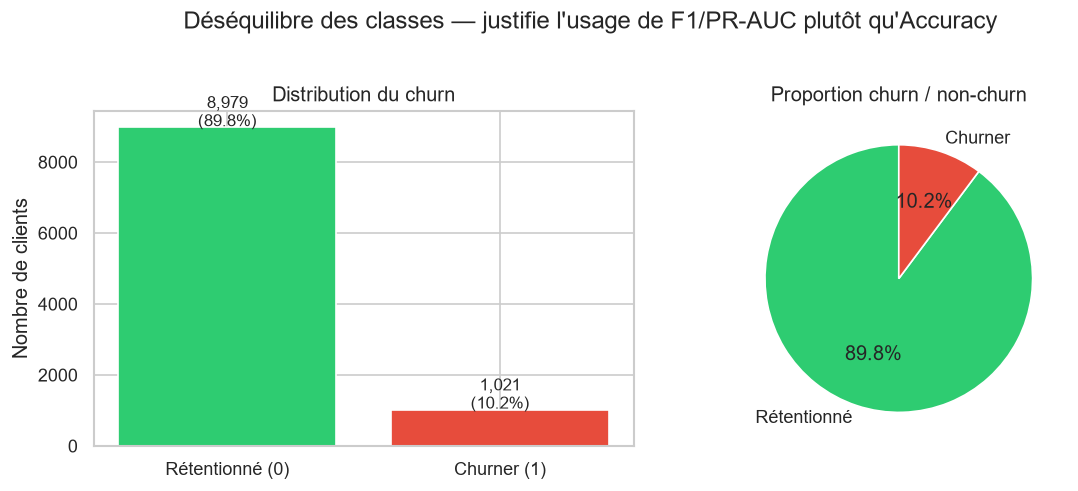

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

counts = df['churn'].value_counts()
axes[0].bar(['Rétentionné (0)', 'Churner (1)'], counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribution du churn')
axes[0].set_ylabel('Nombre de clients')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, f'{v:,}\n({v/n_total:.1%})', ha='center', fontsize=10)

axes[1].pie(counts.values, labels=['Rétentionné', 'Churner'],
            colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proportion churn / non-churn')

plt.suptitle('Déséquilibre des classes — justifie l\'usage de F1/PR-AUC plutôt qu\'Accuracy', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/01_class_distribution.png', bbox_inches='tight')
plt.show()

## 4. Corrélation numérique (Pearson / Spearman)

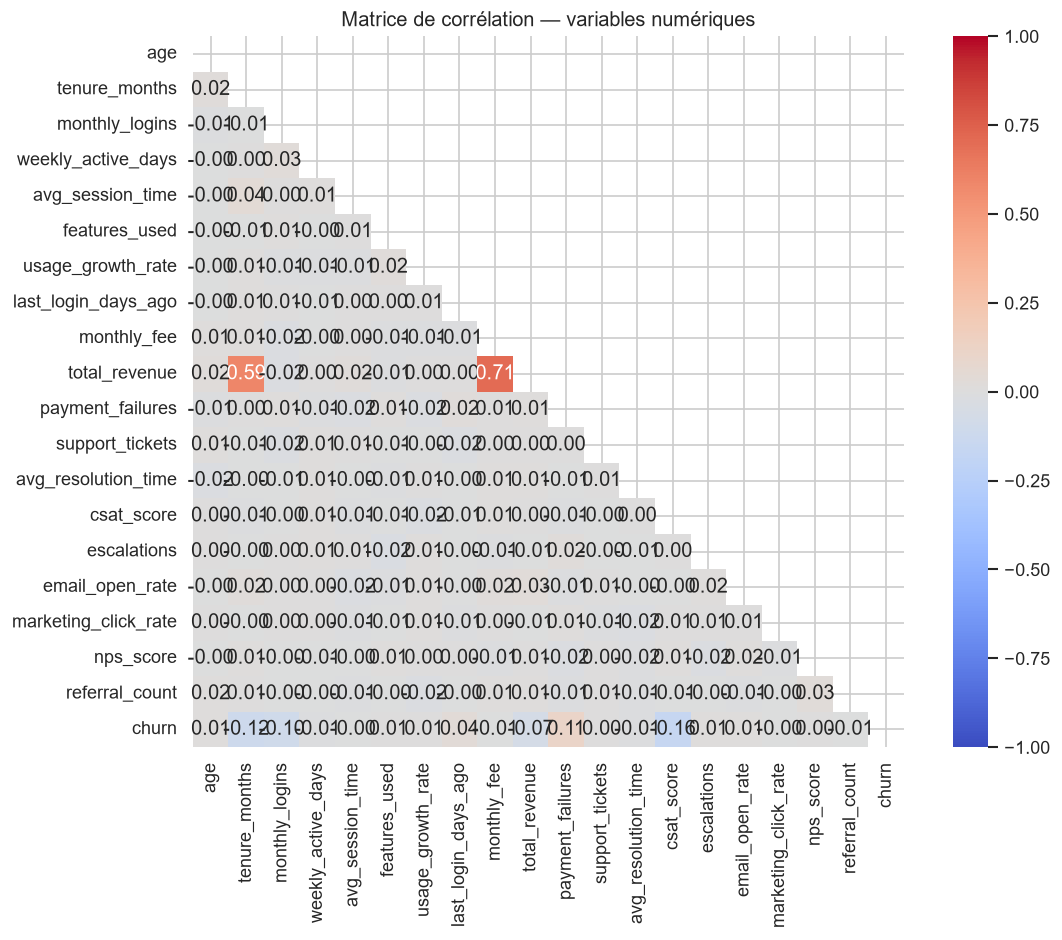

In [6]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title('Matrice de corrélation — variables numériques')
plt.tight_layout()
plt.savefig('../reports/figures/01_correlation_numeric.png', bbox_inches='tight')
plt.show()

## 5. Corrélation catégorielle — Cramér's V

La corrélation de Pearson ne s'applique qu'aux variables numériques. Pour les variables catégorielles (type de contrat, canal d'acquisition, segment client…), il faut une autre mesure : **Cramér's V**, basée sur le test du chi².

Elle varie entre 0 (aucune association) et 1 (association parfaite), et permet de voir si, par exemple, un type de contrat est systématiquement associé au churn.

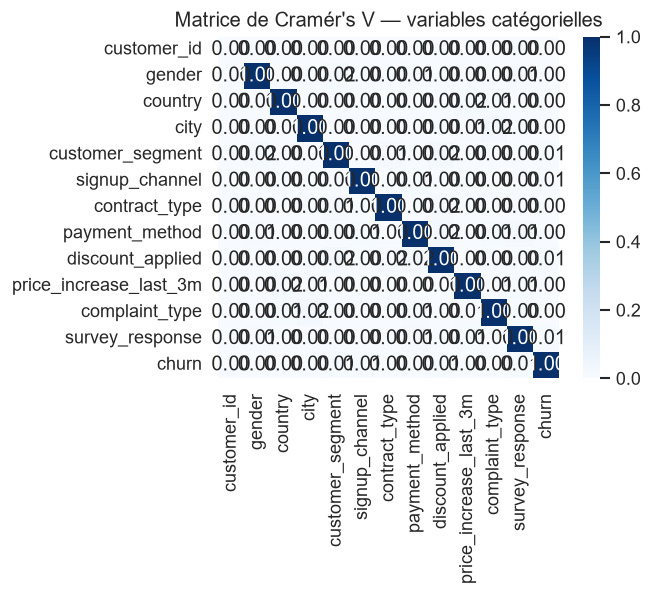


Association avec le churn (Cramér's V) :
survey_response           0.008877
customer_segment          0.008515
discount_applied          0.008060
signup_channel            0.007517
city                      0.000000
country                   0.000000
gender                    0.000000
customer_id               0.000000
payment_method            0.000000
contract_type             0.000000
price_increase_last_3m    0.000000
complaint_type            0.000000
Name: churn, dtype: float64


In [7]:
def cramers_v(x: pd.Series, y: pd.Series) -> float:
    """Compute Cramér's V statistic for two categorical variables."""
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n    = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    # Correction de biais
    phi2corr = max(0, phi2 - ((k-1)*(r-1)) / (n-1))
    rcorr    = r - ((r-1)**2) / (n-1)
    kcorr    = k - ((k-1)**2) / (n-1)
    denom    = min(kcorr-1, rcorr-1)
    if denom <= 0:
        return 0.0
    return np.sqrt(phi2corr / denom)


# Inclure 'churn' comme catégorielle pour voir l'association avec toutes les autres
cat_cols = df.select_dtypes(include='object').columns.tolist() + ['churn']

cramers_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)
for col1 in cat_cols:
    for col2 in cat_cols:
        cramers_matrix.loc[col1, col2] = cramers_v(df[col1].astype(str), df[col2].astype(str))

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cramers_matrix.astype(float), annot=True, fmt='.2f', cmap='Blues',
            vmin=0, vmax=1, ax=ax, square=True)
ax.set_title("Matrice de Cramér's V — variables catégorielles")
plt.tight_layout()
plt.savefig('../reports/figures/01_cramers_v.png', bbox_inches='tight')
plt.show()

print('\nAssociation avec le churn (Cramér\'s V) :')
print(cramers_matrix['churn'].drop('churn').sort_values(ascending=False))

## 6. Analyse bivariée — variables clés vs. churn

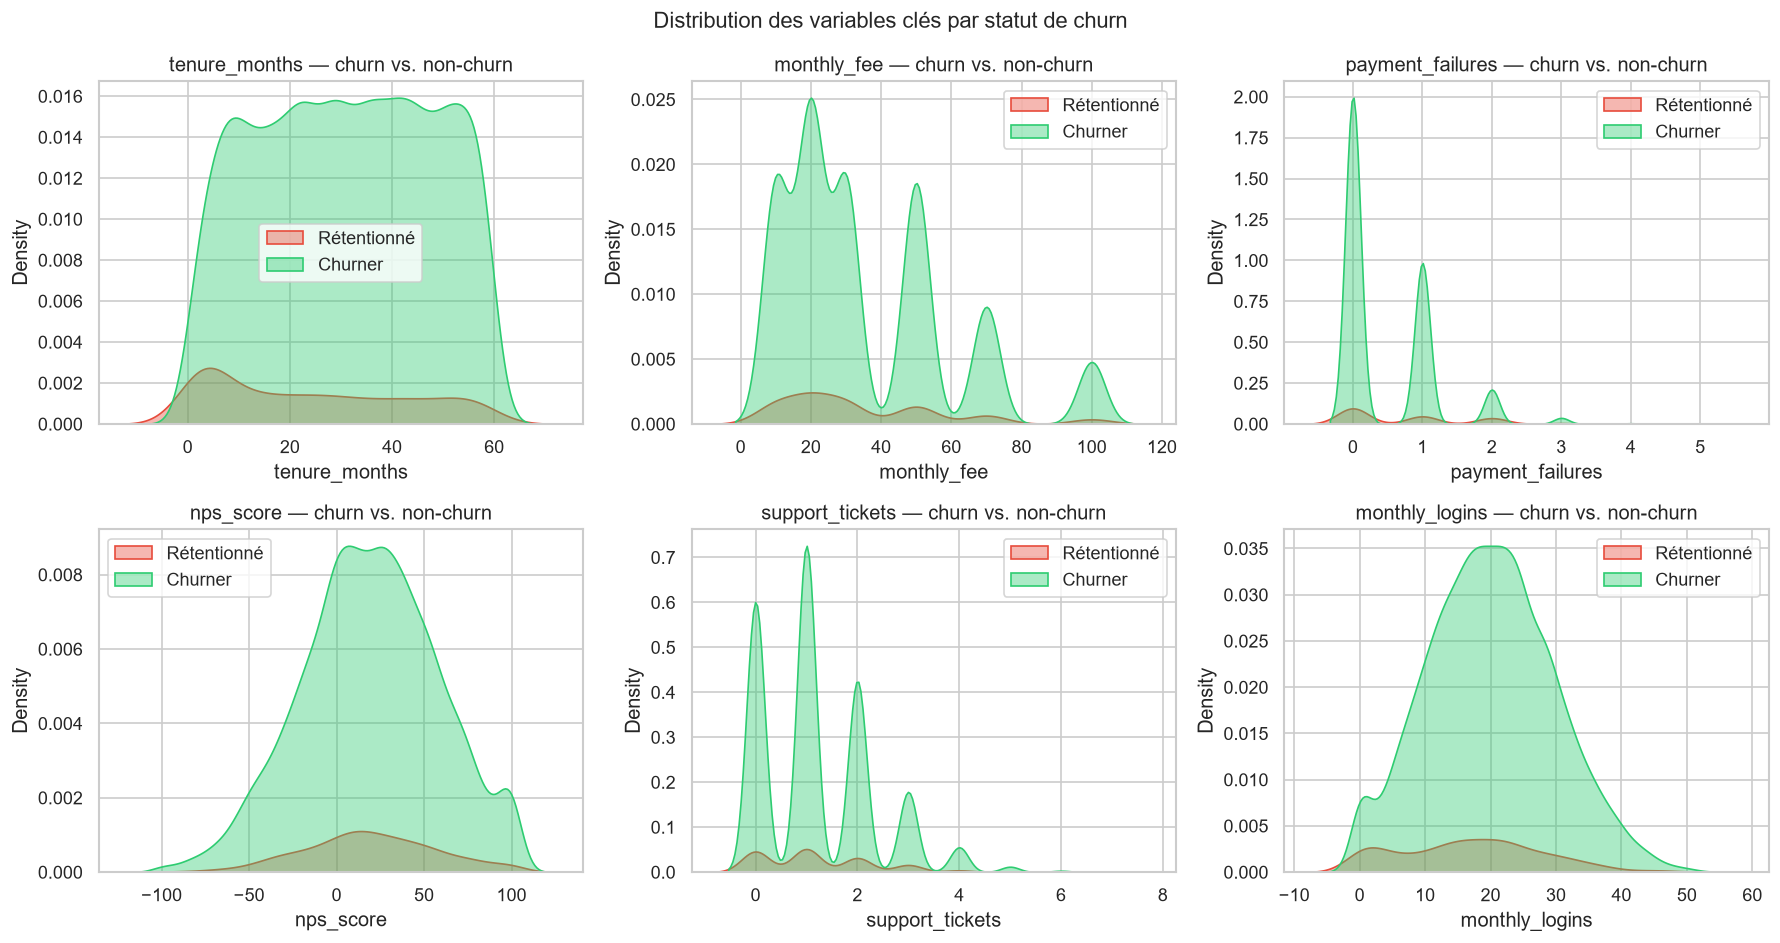

In [8]:
key_vars = ['tenure_months', 'monthly_fee', 'payment_failures', 'nps_score', 'support_tickets', 'monthly_logins']
available = [v for v in key_vars if v in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, var in enumerate(available):
    sns.kdeplot(data=df, x=var, hue='churn', ax=axes[i], fill=True, alpha=0.4,
                palette={0: '#2ecc71', 1: '#e74c3c'})
    axes[i].set_title(f'{var} — churn vs. non-churn')
    axes[i].legend(['Rétentionné', 'Churner'])

plt.suptitle('Distribution des variables clés par statut de churn', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/figures/01_bivariate.png', bbox_inches='tight')
plt.show()

## 7. Détection d'outliers (IQR)

In [9]:
outlier_report = {}
for col in key_vars:
    if col not in df.columns:
        continue
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    outlier_report[col] = {'Q1': Q1, 'Q3': Q3, 'IQR': IQR, 'n_outliers': n_out, 'pct': n_out/len(df)*100}

pd.DataFrame(outlier_report).T.round(2)

,Q1,Q3,IQR,n_outliers,pct
tenure_months,16.0,45.0,29.0,0.0,0.00
monthly_fee,20.0,50.0,30.0,513.0,5.13
payment_failures,0.0,1.0,1.0,147.0,1.47
nps_score,-7.0,46.0,53.0,36.0,0.36
support_tickets,0.0,2.0,2.0,18.0,0.18
monthly_logins,13.0,26.0,13.0,49.0,0.49


## 8. Variables dérivées prometteuses

In [10]:
df_eng = df.copy()
df_eng['tickets_per_tenure']  = df_eng['support_tickets'] / (df_eng['tenure_months'] + 1)
df_eng['fee_per_tenure']  = df_eng['monthly_fee'] / (df_eng['tenure_months'] + 1)

for feat in ['tickets_per_tenure', 'fee_per_tenure']:
    corr_with_churn = df_eng[feat].corr(df_eng['churn'])
    print(f'{feat}: corrélation avec churn = {corr_with_churn:.4f}')
    
print('\n→ Ces features seront ajoutées au pipeline de modélisation si leur corrélation est positive.')

tickets_per_tenure: corrélation avec churn = 0.1217
fee_per_tenure: corrélation avec churn = 0.1424

→ Ces features seront ajoutées au pipeline de modélisation si leur corrélation est positive.


## 9. Synthèse EDA

| Observation | Implication pour la modélisation |
|---|---|
| 10.2% de churners — classes très déséquilibrées | Priorité à F1 et PR-AUC ; `class_weight='balanced'` indispensable |
| `csat_score` et `monthly_fee` — signal fort sur le churn | Variables attendues en tête de l'importance SHAP |
| `contract_type` — association Cramér's V significative | Encoder soigneusement, ne pas agréger avec d'autres catégories |
| Nouveaux clients (tenure < 12 mois) plus à risque | `fee_per_tenure` : corrélation +0.14 avec le churn, à intégrer dans le pipeline |
| `complaint_type` : 20% de valeurs manquantes | Imputation "Unknown" — l'absence de plainte déclarée est en soi une information |

**Ce que révèle l'EDA :** le churn n'est pas un signal simple. L'insatisfaction visible (CSAT bas, NPS négatif, tickets support) coexiste avec des profils récents qui partent sans laisser de trace apparente. Le modèle devra capturer ces deux logiques différentes.

**Prochaine étape :** `02_preprocessing.ipynb` — construire le pipeline en évitant toute fuite de données.